In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import glob
import json
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("/code")
import bg_spatial_plots.plot_spatial_histograms as histplot
from plot_confusion_matrix import plot_confusion_matrix

%matplotlib inline

# Plotting params

In [3]:
output_fig_dir = '/scratch/mat_paper_figures/for_YF_astro'
os.makedirs(output_fig_dir, exist_ok=True)

from bg_spatial_plots._fonts import register_arial_fonts
register_arial_fonts()  # sets default font to Arial & TrueType fonts for vector formats
plt.rcParams.update({'font.size': 6})  # default for labels, legends, etc.

# to get text as text and not paths in Illustrator
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

# this can mess with some plots, use cautiously
# plt.rcParams['figure.constrained_layout.use'] = True

subgroup_color_palette = {
    'GM STR': '#487cb4',
    'GM exSTR': '#65ab55',
    'WM': '#d23b33',
    'Mixed': '#999999',
}

# Astro subgroup params

In [4]:
subgroup_cluster_dict = {
    'GM STR': ['h-7', 'h-14', 'h-31'],
    'GM exSTR': [
        'h-145',
        'h-146',
        'h-149',
        'h-150',
        'h-152',
        'h-159',
        'h-160',
        'h-450',
        'h-452'
    ],
    'WM': ['h-28', 'h-227', 'h-230', 'h-231', 'h-472', 'h-479', 'h-485'],
    'Mixed': ['h-143', 'h-232']
}

# replace h- with Human-
subgroup_cluster_dict = {k: [c.replace('h-', 'Human-') for c in v] for k, v in subgroup_cluster_dict.items()}
subgroup_cluster_dict

# invert the dictionary to get cluster to subgroup mapping
cluster_subgroup_dict = {c: k for k, v in subgroup_cluster_dict.items() for c in v}
cluster_subgroup_dict

{'Human-7': 'GM STR',
 'Human-14': 'GM STR',
 'Human-31': 'GM STR',
 'Human-145': 'GM exSTR',
 'Human-146': 'GM exSTR',
 'Human-149': 'GM exSTR',
 'Human-150': 'GM exSTR',
 'Human-152': 'GM exSTR',
 'Human-159': 'GM exSTR',
 'Human-160': 'GM exSTR',
 'Human-450': 'GM exSTR',
 'Human-452': 'GM exSTR',
 'Human-28': 'WM',
 'Human-227': 'WM',
 'Human-230': 'WM',
 'Human-231': 'WM',
 'Human-472': 'WM',
 'Human-479': 'WM',
 'Human-485': 'WM',
 'Human-143': 'Mixed',
 'Human-232': 'Mixed'}

# Load data

In [5]:
# adata_spatial = ad.read_h5ad('/data/cirro_files_hmba_human_20250922/hmba_release_format_human_cirro_h5ad_20250922.h5ad')
# adata_spatial

In [6]:
adata_spatial_astro_extended = ad.read_h5ad('/scratch/astrocytes/human_spatial_astrocytes_extended_mmc_results_UMAP_colors.h5ad')
adata_spatial_astro_extended

AnnData object with n_obs × n_vars = 641913 × 299
    obs: 'x', 'y', 'brain_section_label', 'brain_section_barcode', 'slab', 'block', 'set', 'z_order', 'total_counts', 'total_counts_genes', 'n_genes_by_counts', 'total_counts_Blank', 'pct_counts_Blank', 'genes_filter', 'counts_filter', 'blanks_filter', 'qc_pass', 'doublets_filter', 'qc_pass_and_singlet', 'doublet_singlet_score_diff', 'doublet_diff_threshold', 'hierarchy_consistent', 'Neighborhood', 'Neighborhood_bootstrapping_probability', 'Neighborhood_correlation_coefficient', 'Class', 'Class_bootstrapping_probability', 'Class_correlation_coefficient', 'Subclass', 'Subclass_bootstrapping_probability', 'Subclass_correlation_coefficient', 'Group', 'Group_bootstrapping_probability', 'Group_correlation_coefficient', 'cluster_id', 'cluster_id_bootstrapping_probability', 'cluster_id_correlation_coefficient', 'Neighborhood_entropy', 'Class_entropy', 'Subclass_entropy', 'Group_entropy', 'cluster_id_entropy', 'STAligner_mclust_res_10_knn_15', 

In [7]:
adata_spatial_remap = ad.read_h5ad('/data/human_spatial_astrocyte_MMC_results_with_Astro_SubGroups/human_spatial_astrocytes_extended_mmc_results_UMAP_colors_mmc_mapped-withAstroSubGroups.h5ad')
adata_spatial_remap

AnnData object with n_obs × n_vars = 641913 × 299
    obs: 'x', 'y', 'brain_section_label', 'brain_section_barcode', 'slab', 'block', 'set', 'z_order', 'total_counts', 'total_counts_genes', 'n_genes_by_counts', 'total_counts_Blank', 'pct_counts_Blank', 'genes_filter', 'counts_filter', 'blanks_filter', 'qc_pass', 'doublets_filter', 'qc_pass_and_singlet', 'doublet_singlet_score_diff', 'doublet_diff_threshold', 'hierarchy_consistent', 'Neighborhood', 'Neighborhood_bootstrapping_probability', 'Neighborhood_correlation_coefficient', 'Class', 'Class_bootstrapping_probability', 'Class_correlation_coefficient', 'Subclass', 'Subclass_bootstrapping_probability', 'Subclass_correlation_coefficient', 'Group', 'Group_bootstrapping_probability', 'Group_correlation_coefficient', 'cluster_id', 'cluster_id_bootstrapping_probability', 'cluster_id_correlation_coefficient', 'Neighborhood_entropy', 'Class_entropy', 'Subclass_entropy', 'Group_entropy', 'cluster_id_entropy', 'STAligner_mclust_res_10_knn_15', 

In [8]:
adata_rnaseq = ad.read_h5ad(
    '/data/snRNAseq_hmba_bg_human_astro_3subGroups/HMBA_human_Astro_3subGroups.h5ad',
)
adata_rnaseq

AnnData object with n_obs × n_vars = 134124 × 36601
    obs: 'Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster', 'donor_id', 'anatomical_region', 'anatomical_region_merged', 'anatomical_region_ontology_term_id', 'self_reported_sex', 'self_reported_sex_ontology_term_id', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'disease', 'disease_ontology_term_id', 'suspension_type', 'is_primary_data', 'atac_confidently_mapped_read_pairs', 'atac_fraction_of_genome_in_peaks', 'atac_fraction_of_high_quality_fragments_in_cells', 'atac_fraction_of_high_quality_fragments_overlapping_tss', 'atac_fraction_of_high_quality_fragments_overlapping_peaks', 'atac_fraction_of_transposition_events_in_peaks_in_cells', 'atac_mean_raw_read_pairs_per_cell', 'atac_median_high_quality_fragments_per_cell', 'atac_non_nuclear_read_pairs', 'atac_number_of_peaks', 'atac_percent_duplicates', 'atac_q30_bases_in_barcode', 'atac_q30_bases_in_read_1', 'atac_q30_bases_in_read_2', 'atac_q30_bases_in_s

# Mapping QC metrics

In [8]:
sorted(adata_spatial_astro_extended.obs.columns.tolist())

['Class',
 'Class_avg_correlation',
 'Class_bootstrapping_probability',
 'Class_bootstrapping_probability_extended',
 'Class_correlation_coefficient',
 'Class_entropy',
 'Class_extended',
 'Class_runner_up_1',
 'Class_runner_up_1_correlation',
 'Class_runner_up_1_probability',
 'Class_runner_up_2',
 'Class_runner_up_2_correlation',
 'Class_runner_up_2_probability',
 'Class_runner_up_3',
 'Class_runner_up_3_correlation',
 'Class_runner_up_3_probability',
 'Class_runner_up_4',
 'Class_runner_up_4_correlation',
 'Class_runner_up_4_probability',
 'Class_runner_up_5',
 'Class_runner_up_5_correlation',
 'Class_runner_up_5_probability',
 'Cluster',
 'GP',
 'GPe',
 'GPi',
 'Group',
 'Group_avg_correlation',
 'Group_bootstrapping_probability',
 'Group_bootstrapping_probability_extended',
 'Group_correlation_coefficient',
 'Group_entropy',
 'Group_extended',
 'Group_runner_up_1',
 'Group_runner_up_1_correlation',
 'Group_runner_up_1_probability',
 'Group_runner_up_2',
 'Group_runner_up_2_correla

### Average correlation

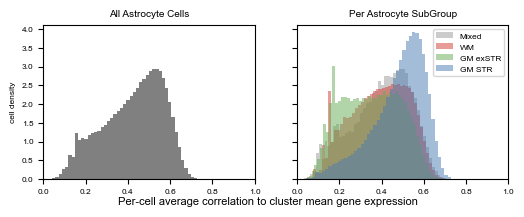

In [9]:
# Include mixed
fig, axes = plt.subplots(1, 2, figsize=(6, 2), sharey=True)

axes[0].hist(adata_spatial_astro_extended.obs['cluster_id_avg_correlation'], bins=50, color='gray', density=True)
axes[0].set_title('All Astrocyte Cells')
axes[0].set_ylabel('cell density')

for i, subgroup in enumerate(['Mixed', 'WM', 'GM exSTR', 'GM STR',]):
    subgroup_data = adata_spatial_astro_extended.obs[adata_spatial_astro_extended.obs['SubGroup_extended'] == subgroup]
    axes[1].hist(subgroup_data['cluster_id_avg_correlation'], bins=50, alpha=0.5, label=subgroup, density=True, color=subgroup_color_palette[subgroup])
    axes[1].set_title('Per Astrocyte SubGroup')
    axes[1].legend()

for ax in axes:
    ax.set_xlim(0, 1)

# set global xlabel
fig.text(0.5, -0.02, 'Per-cell average correlation to cluster mean gene expression', ha='center', fontsize=8)

fig.savefig(os.path.join(output_fig_dir, 'spatial_astro_avg_corr_per_group_hist_withMixed.png'), bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(output_fig_dir, 'spatial_astro_avg_corr_per_group_hist_withMixed.pdf'), bbox_inches='tight')

plt.show()


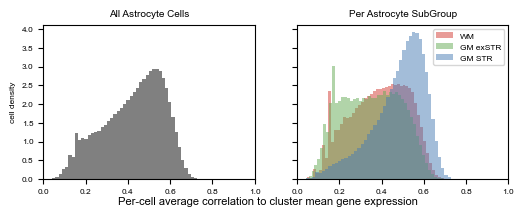

In [10]:
# Exclude Mixed
fig, axes = plt.subplots(1, 2, figsize=(6, 2), sharey=True)

axes[0].hist(adata_spatial_astro_extended.obs['cluster_id_avg_correlation'], bins=50, color='gray', density=True)
axes[0].set_title('All Astrocyte Cells')
axes[0].set_ylabel('cell density')

for i, subgroup in enumerate(['WM', 'GM exSTR', 'GM STR',]):
    subgroup_data = adata_spatial_astro_extended.obs[adata_spatial_astro_extended.obs['SubGroup_extended'] == subgroup]
    axes[1].hist(subgroup_data['cluster_id_avg_correlation'], bins=50, alpha=0.5, label=subgroup, density=True, color=subgroup_color_palette[subgroup])
    axes[1].set_title('Per Astrocyte SubGroup')
    axes[1].legend()

for ax in axes:
    ax.set_xlim(0, 1)

# set global xlabel
fig.text(0.5, -0.02, 'Per-cell average correlation to cluster mean gene expression', ha='center', fontsize=8)

fig.savefig(os.path.join(output_fig_dir, 'spatial_astro_avg_corr_per_group_hist.png'), bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(output_fig_dir, 'spatial_astro_avg_corr_per_group_hist.pdf'), bbox_inches='tight')

plt.show()

SubGroup: Mixed, Number of Clusters: 2


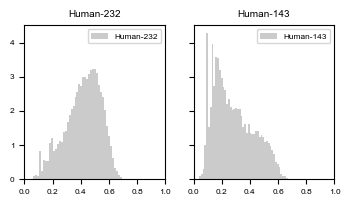

SubGroup: WM, Number of Clusters: 7


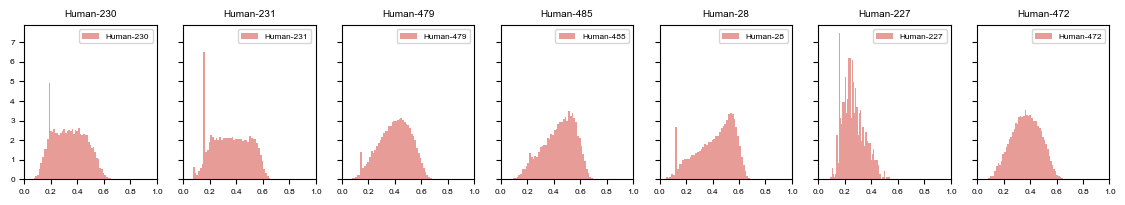

SubGroup: GM exSTR, Number of Clusters: 9


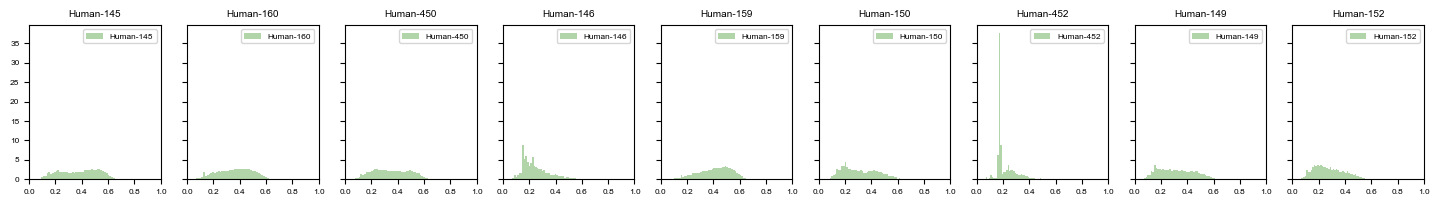

SubGroup: GM STR, Number of Clusters: 3


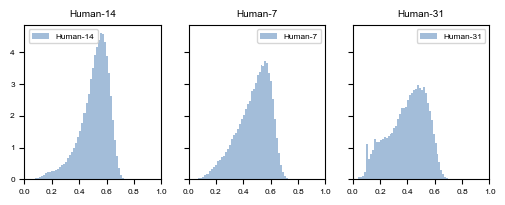

In [11]:
# for each cluster
for subgroup in ['Mixed', 'WM', 'GM exSTR', 'GM STR',]:
    subgroup_data = adata_spatial_astro_extended.obs[adata_spatial_astro_extended.obs['SubGroup_extended'] == subgroup]
    n_clusters = subgroup_data['cluster_id_extended'].nunique()
    print(f'SubGroup: {subgroup}, Number of Clusters: {n_clusters}')
    fig, axes = plt.subplots(1, n_clusters, figsize=(n_clusters*2, 2), sharey=True)
    for i, cluster in enumerate(subgroup_data['cluster_id_extended'].unique()):
        cluster_data = subgroup_data[subgroup_data['cluster_id_extended'] == cluster]
        axes[i].hist(cluster_data['cluster_id_avg_correlation'], bins=50, alpha=0.5, label=cluster, density=True, color=subgroup_color_palette[subgroup])
        axes[i].set_title(cluster)
        axes[i].legend()
        axes[i].set_xlim(0, 1)
    plt.show()

/tmp/ipykernel_7587/4030227591.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_7587/4030227591.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_7587/4030227591.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90, fontsize=5)


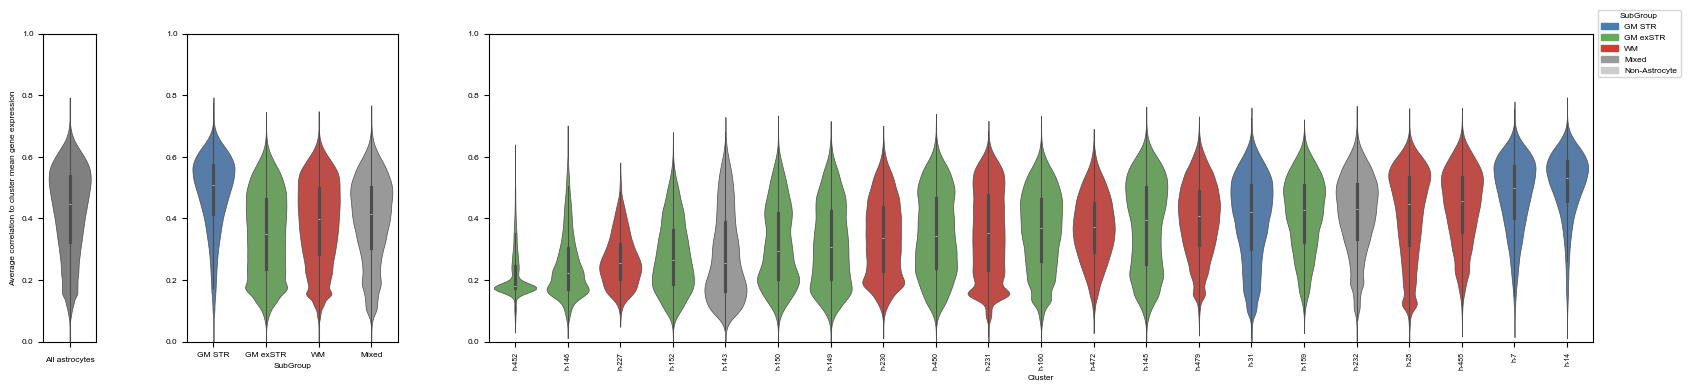

In [ ]:
# Build obs dataframe with SubGroup info for coloring
obs = adata_spatial_astro_extended.obs.copy()
obs['SubGroup'] = obs['cluster_id_extended'].map(cluster_subgroup_dict)
obs['cluster_id_h'] = obs['cluster_id_extended'].astype(str).str.replace('Human-', 'h-', regex=False)

# Compute mean correlation per cluster and sort
cluster_means = (
    obs.groupby('cluster_id_h', observed=True)['cluster_id_avg_correlation']
    .mean()
    .reset_index()
    .rename(columns={'cluster_id_avg_correlation': 'mean_corr'})
)
cluster_means['SubGroup'] = cluster_means['cluster_id_h'].map(
    obs.drop_duplicates('cluster_id_h').set_index('cluster_id_h')['SubGroup']
)
cluster_means = cluster_means.sort_values('mean_corr', ascending=True)
cluster_order = cluster_means['cluster_id_h'].tolist()
per_cluster_palette = [
    subgroup_color_palette.get(
        cluster_means.loc[cluster_means['cluster_id_h'] == c, 'SubGroup'].values[0], '#cccccc'
    )
    for c in cluster_order
]

astro_subgroups = ['GM STR', 'GM exSTR', 'WM', 'Mixed']
n_clusters = len(cluster_order)

# 3 rows: (1) all astros, (2) per subgroup, (3) per cluster
# Use gridspec so row 3 is taller
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(20, 4))
gs = GridSpec(1, 3, figure=fig, width_ratios=[1, 4, 21], wspace=0.2)

# --- Row 0: single violin, all astrocytes combined ---
ax0 = fig.add_subplot(gs[0])
sns.violinplot(
    y='cluster_id_avg_correlation',
    data=obs[obs['SubGroup'] != 'Non-Astrocyte'],
    color='gray',
    inner='box',
    linewidth=0.5,
    ax=ax0,
)
ax0.set_xlabel('All astrocytes')
ax0.set_ylabel('Average correlation to cluster mean gene expression')
ax0.set_ylim(0, 1)

# --- Row 1: one violin per subgroup ---
ax1 = fig.add_subplot(gs[1])
sg_order = astro_subgroups
sg_palette = [subgroup_color_palette[sg] for sg in sg_order]
sns.violinplot(
    x='SubGroup',
    y='cluster_id_avg_correlation',
    data=obs[obs['SubGroup'].isin(astro_subgroups)],
    order=sg_order,
    palette=sg_palette,
    inner='box',
    linewidth=0.5,
    ax=ax1,
)
ax1.set_xlabel('SubGroup')
ax1.set_ylabel('')
ax1.set_ylim(0, 1)

# --- Row 2: one violin per cluster ---
ax2 = fig.add_subplot(gs[2])
sns.violinplot(
    x='cluster_id_h',
    y='cluster_id_avg_correlation',
    data=obs,
    order=cluster_order,
    palette=per_cluster_palette,
    inner='box',
    linewidth=0.5,
    ax=ax2,
)
ax2.set_xlabel('Cluster')
ax2.set_ylabel('')
ax2.set_ylim(0, 1)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90, fontsize=5)

# shared legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=sg) for sg, c in subgroup_color_palette.items()]
legend_handles.append(Patch(color='#cccccc', label='Non-Astrocyte'))
fig.legend(handles=legend_handles, title='SubGroup', bbox_to_anchor=(0.90, 0.95), loc='upper left', fontsize=6)

fig.savefig(os.path.join(output_fig_dir, 'spatial_astro_avg_corr_violin_3col.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(output_fig_dir, 'spatial_astro_avg_corr_violin_3col.png'), dpi=300, bbox_inches='tight')
plt.show()

### Bootstrapping probability

/tmp/ipykernel_7587/875723290.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_7587/875723290.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_7587/875723290.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90, fontsize=5)


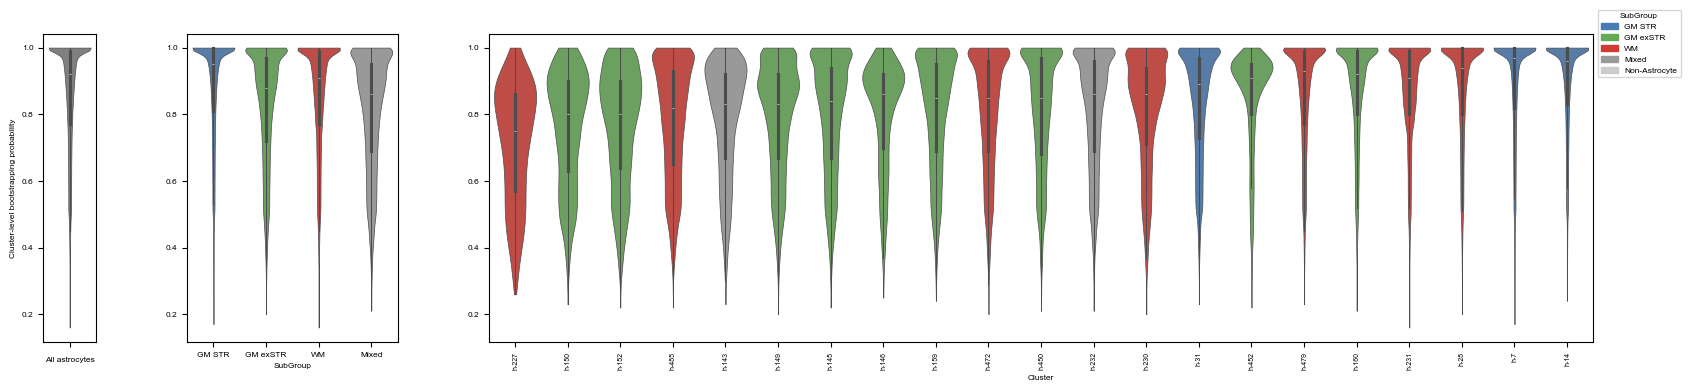

In [13]:
# Build obs dataframe with SubGroup info for coloring
obs = adata_spatial_astro_extended.obs.copy()
obs['SubGroup'] = obs['cluster_id_extended'].map(cluster_subgroup_dict)
obs['cluster_id_short'] = obs['cluster_id_extended'].astype(str).str.replace('Human-', 'h-', regex=False)

# Compute mean correlation per cluster and sort
cluster_means = (
    obs.groupby('cluster_id_short', observed=True)['cluster_id_bootstrapping_probability']
    .mean()
    .reset_index()
    .rename(columns={'cluster_id_bootstrapping_probability': 'mean_corr'})
)
cluster_means['SubGroup'] = cluster_means['cluster_id_short'].map(
    obs.drop_duplicates('cluster_id_short').set_index('cluster_id_short')['SubGroup']
)
cluster_means = cluster_means.sort_values('mean_corr', ascending=True)
cluster_order = cluster_means['cluster_id_short'].tolist()
per_cluster_palette = [
    subgroup_color_palette.get(
        cluster_means.loc[cluster_means['cluster_id_short'] == c, 'SubGroup'].values[0], '#cccccc'
    )
    for c in cluster_order
]

astro_subgroups = ['GM STR', 'GM exSTR', 'WM', 'Mixed']
n_clusters = len(cluster_order)

# 3 rows: (1) all astros, (2) per subgroup, (3) per cluster
# Use gridspec so row 3 is taller
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(20, 4))
gs = GridSpec(1, 3, figure=fig, width_ratios=[1, 4, 21], wspace=0.2)

# --- Row 0: single violin, all astrocytes combined ---
ax0 = fig.add_subplot(gs[0])
sns.violinplot(
    y='cluster_id_bootstrapping_probability',
    data=obs[obs['SubGroup'] != 'Non-Astrocyte'],
    color='gray',
    inner='box',
    linewidth=0.5,
    ax=ax0,
    cut=0
)
ax0.set_xlabel('All astrocytes')
ax0.set_ylabel('Cluster-level bootstrapping probability')
# ax0.set_ylim(0, 1)

# --- Row 1: one violin per subgroup ---
ax1 = fig.add_subplot(gs[1])
sg_order = astro_subgroups
sg_palette = [subgroup_color_palette[sg] for sg in sg_order]
sns.violinplot(
    x='SubGroup',
    y='cluster_id_bootstrapping_probability',
    data=obs[obs['SubGroup'].isin(astro_subgroups)],
    order=sg_order,
    palette=sg_palette,
    inner='box',
    linewidth=0.5,
    ax=ax1,
    cut=0
)
ax1.set_xlabel('SubGroup')
ax1.set_ylabel('')
# ax1.set_ylim(0, 1)

# --- Row 2: one violin per cluster ---
ax2 = fig.add_subplot(gs[2])
sns.violinplot(
    x='cluster_id_short',
    y='cluster_id_bootstrapping_probability',
    data=obs,
    order=cluster_order,
    palette=per_cluster_palette,
    inner='box',
    linewidth=0.5,
    ax=ax2,
    cut=0
)
ax2.set_xlabel('Cluster')
ax2.set_ylabel('')
# ax2.set_ylim(0, 1)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90, fontsize=5)

# shared legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=sg) for sg, c in subgroup_color_palette.items()]
legend_handles.append(Patch(color='#cccccc', label='Non-Astrocyte'))
fig.legend(handles=legend_handles, title='SubGroup', bbox_to_anchor=(0.90, 0.95), loc='upper left', fontsize=6)

fig.savefig(os.path.join(output_fig_dir, 'spatial_astro_cluster_bootstrap_prob_violin_3col.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(output_fig_dir, 'spatial_astro_cluster_bootstrap_prob_violin_3col.png'), dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_71744/2060437640.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


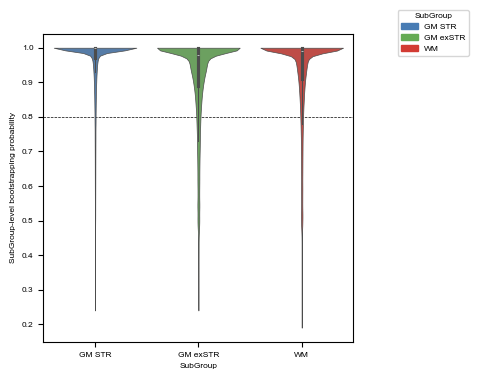

/tmp/ipykernel_71744/2060437640.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_71744/2060437640.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90, fontsize=5)


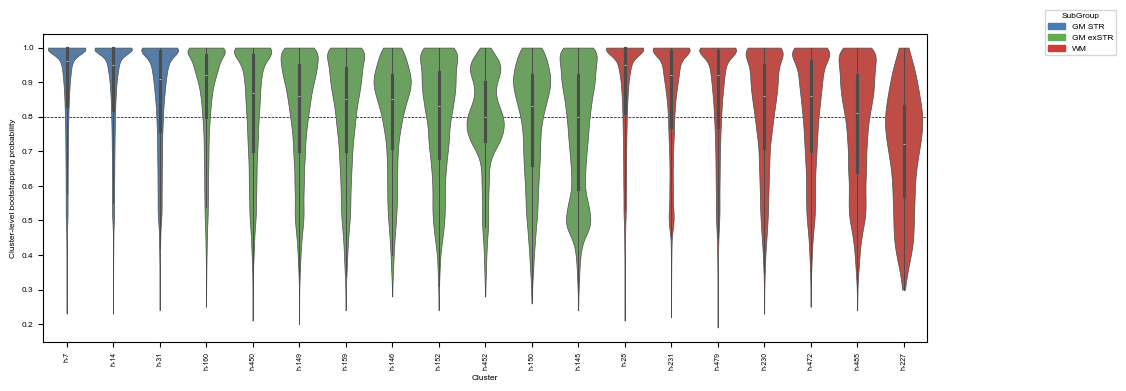

In [18]:
# Build obs dataframe with SubGroup info for coloring
obs = adata_spatial_remap.obs.copy()
# obs['SubGroup'] = obs['cluster_id_extended'].map(cluster_subgroup_dict)
obs['cluster_id_h'] = obs['CDM_cluster_id_label'].astype(str).str.replace('Human-', 'h-', regex=False)

astro_subgroups = ['GM STR', 'GM exSTR', 'WM']  # excludes Mixed, defines SubGroup order

# Compute mean bootstrapping probability per cluster and sort within each SubGroup
cluster_means = (
    obs.groupby('cluster_id_h', observed=True)['CDM_cluster_id_bootstrapping_probability']
    .mean()
    .reset_index()
    .rename(columns={'CDM_cluster_id_bootstrapping_probability': 'mean_val'})
)
cluster_means['SubGroup'] = cluster_means['cluster_id_h'].map(
    obs.drop_duplicates('cluster_id_h').set_index('cluster_id_h')['CDM_SubGroup_label']
)
# Drop Mixed clusters
cluster_means = cluster_means[cluster_means['SubGroup'].isin(astro_subgroups)]
# Sort by SubGroup order first, then by mean value within each SubGroup
cluster_means['SubGroup'] = pd.Categorical(cluster_means['SubGroup'], categories=astro_subgroups, ordered=True)
cluster_means = cluster_means.sort_values(['SubGroup', 'mean_val'], ascending=[True, False])
cluster_order = cluster_means['cluster_id_h'].tolist()
per_cluster_palette = [
    subgroup_color_palette.get(
        cluster_means.loc[cluster_means['cluster_id_h'] == c, 'SubGroup'].values[0], '#cccccc'
    )
    for c in cluster_order
]

n_clusters = len(cluster_order)

from matplotlib.patches import Patch
legend_handles = [Patch(color=subgroup_color_palette[sg], label=sg) for sg in astro_subgroups]

PLOT_HEIGHT = 4

# # --- Plot 0: single violin, all astrocytes combined ---
# fig0, ax0 = plt.subplots(figsize=(1.5, PLOT_HEIGHT))
# sns.violinplot(
#     y='cluster_id_bootstrapping_probability',
#     data=obs[obs['CDM_SubGroup_label'].isin(astro_subgroups)],
#     color='gray',
#     inner='box',
#     linewidth=0.5,
#     ax=ax0,
#     cut=0,
# )
# ax0.set_xlabel('All astrocytes')
# ax0.set_ylabel('Cluster-level bootstrapping probability')
# fig0.legend(handles=legend_handles, title='SubGroup', bbox_to_anchor=(1.0, 0.95), loc='upper left', fontsize=6)
# fig0.savefig(os.path.join(output_fig_dir, 'spatial_astro_cluster_bootstrap_prob_violin_all.pdf'), bbox_inches='tight')
# fig0.savefig(os.path.join(output_fig_dir, 'spatial_astro_cluster_bootstrap_prob_violin_all.png'), dpi=300, bbox_inches='tight')
# plt.show()

# --- Plot 1: one violin per subgroup ---
fig1, ax1 = plt.subplots(figsize=(4, PLOT_HEIGHT))
sg_palette = [subgroup_color_palette[sg] for sg in astro_subgroups]
ax1.axhline(0.8, color='black', linestyle='--', linewidth=0.5, zorder=0)
sns.violinplot(
    x='CDM_SubGroup_label',
    y='CDM_SubGroup_bootstrapping_probability',
    data=obs[obs['CDM_SubGroup_label'].isin(astro_subgroups)],
    order=astro_subgroups,
    palette=sg_palette,
    inner='box',
    linewidth=0.5,
    ax=ax1,
    cut=0,
)
ax1.set_xlabel('SubGroup')
ax1.set_ylabel('SubGroup-level bootstrapping probability')
fig1.legend(handles=legend_handles, title='SubGroup', bbox_to_anchor=(1.0, 0.95), loc='upper left', fontsize=6)
fig1.savefig(os.path.join(output_fig_dir, 'spatial_astro_subgroup_bootstrap_prob_violin_per_subgroup.pdf'), bbox_inches='tight')
fig1.savefig(os.path.join(output_fig_dir, 'spatial_astro_subgroup_bootstrap_prob_violin_per_subgroup.png'), dpi=300, bbox_inches='tight')
plt.show()

# --- Plot 2: one violin per cluster ---
fig2, ax2 = plt.subplots(figsize=(n_clusters * 0.6, PLOT_HEIGHT))
ax2.axhline(0.8, color='black', linestyle='--', linewidth=0.5, zorder=0)
sns.violinplot(
    x='cluster_id_h',
    y='CDM_cluster_id_bootstrapping_probability',
    data=obs[obs['CDM_SubGroup_label'].isin(astro_subgroups)],
    order=cluster_order,
    palette=per_cluster_palette,
    inner='box',
    linewidth=0.5,
    ax=ax2,
    cut=0,
)
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Cluster-level bootstrapping probability')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90, fontsize=5)
fig2.legend(handles=legend_handles, title='SubGroup', bbox_to_anchor=(1.0, 0.95), loc='upper left', fontsize=6)
fig2.savefig(os.path.join(output_fig_dir, 'spatial_astro_cluster_bootstrap_prob_violin_per_cluster.pdf'), bbox_inches='tight')
fig2.savefig(os.path.join(output_fig_dir, 'spatial_astro_cluster_bootstrap_prob_violin_per_cluster.png'), dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# list the median bootstrapping probability per subgroup
subgroup_medians = (
    obs[obs['CDM_SubGroup_label'].isin(astro_subgroups)]
    .groupby('CDM_SubGroup_label', observed=True)['CDM_SubGroup_bootstrapping_probability']
    .median()
    .reset_index()
    .rename(columns={'CDM_SubGroup_bootstrapping_probability': 'median_bootstrap_prob'})
)
print(subgroup_medians)

# per cluster
cluster_medians = (
    obs[obs['CDM_SubGroup_label'].isin(astro_subgroups)]
    .groupby('cluster_id_h', observed=True)['CDM_cluster_id_bootstrapping_probability']
    .median()
    .reset_index()
    .rename(columns={'CDM_cluster_id_bootstrapping_probability': 'median_bootstrap_prob'})
)
print(cluster_medians)

  CDM_SubGroup_label  median_bootstrap_prob
0             GM STR                   1.00
1           GM exSTR                   0.98
2                 WM                   0.99
   cluster_id_h  median_bootstrap_prob
0          h-14                   0.95
1         h-145                   0.80
2         h-146                   0.85
3         h-149                   0.86
4         h-150                   0.83
5         h-152                   0.83
6         h-159                   0.85
7         h-160                   0.92
8         h-227                   0.72
9         h-230                   0.86
10        h-231                   0.92
11         h-28                   0.95
12         h-31                   0.91
13        h-450                   0.87
14        h-452                   0.80
15        h-472                   0.86
16        h-479                   0.92
17        h-485                   0.81
18          h-7                   0.96


In [23]:
# now means
subgroup_means = (
    obs[obs['CDM_SubGroup_label'].isin(astro_subgroups)]
    .groupby('CDM_SubGroup_label', observed=True)['CDM_SubGroup_bootstrapping_probability']
    .mean().round(2)
    .reset_index()
    .rename(columns={'CDM_SubGroup_bootstrapping_probability': 'mean_bootstrap_prob'})
)
print(subgroup_means)

cluster_means = (
    obs[obs['CDM_SubGroup_label'].isin(astro_subgroups)]
    .groupby('cluster_id_h', observed=True)['CDM_cluster_id_bootstrapping_probability']
    .mean().round(2)
    .reset_index()
    .rename(columns={'CDM_cluster_id_bootstrapping_probability': 'mean_bootstrap_prob'})
)
print(cluster_means)

  CDM_SubGroup_label  mean_bootstrap_prob
0             GM STR                 0.96
1           GM exSTR                 0.92
2                 WM                 0.93
   cluster_id_h  mean_bootstrap_prob
0          h-14                 0.88
1         h-145                 0.76
2         h-146                 0.80
3         h-149                 0.81
4         h-150                 0.78
5         h-152                 0.79
6         h-159                 0.81
7         h-160                 0.86
8         h-227                 0.70
9         h-230                 0.81
10        h-231                 0.86
11         h-28                 0.88
12         h-31                 0.85
13        h-450                 0.82
14        h-452                 0.79
15        h-472                 0.81
16        h-479                 0.85
17        h-485                 0.77
18          h-7                 0.89


In [132]:
obs

,x,y,brain_section_label,brain_section_barcode,slab,block,set,z_order,total_counts,total_counts_genes,...,cluster_id_runner_up_5_correlation,cluster_id_runner_up_5_probability,SubGroup_extended,SubGroup_runner_up_1,SubGroup_runner_up_2,SubGroup_runner_up_3,SubGroup_runner_up_4,SubGroup_runner_up_5,SubGroup,cluster_id_short
cell_label,,,,,,,,,,,,,,,,,,,,,
1321115602_26,2952.413818,1081.064819,H22.30.001.CX.16.05.05.03,1321115602,CX.16,5,5,6,101,101,...,NaN,NaN,GM STR,GM STR,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,GM STR,h-14
1321115602_32,2904.200684,1114.436646,H22.30.001.CX.16.05.05.03,1321115602,CX.16,5,5,6,203,203,...,NaN,NaN,GM STR,GM STR,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,GM STR,h-7
1321115602_39,2920.945801,1132.869751,H22.30.001.CX.16.05.05.03,1321115602,CX.16,5,5,6,154,154,...,NaN,NaN,Mixed,GM STR,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,Mixed,h-232
1321115602_41,2844.331299,1148.932739,H22.30.001.CX.16.05.05.03,1321115602,CX.16,5,5,6,228,228,...,NaN,NaN,GM STR,GM STR,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,GM STR,h-7
1321115602_44,3175.939697,1163.299683,H22.30.001.CX.16.05.05.03,1321115602,CX.16,5,5,6,189,188,...,NaN,NaN,GM STR,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,GM STR,h-7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384732991_84452,8126.525391,1141.643066,H22.30.001.CX.20.02.05.01,1384732991,CX.20,2,5,16,120,120,...,NaN,NaN,WM,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,WM,h-479
1384732991_84453,7888.952148,1144.162354,H22.30.001.CX.20.02.05.01,1384732991,CX.20,2,5,16,83,83,...,NaN,NaN,WM,Mixed,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,WM,h-479
1384732991_84461,8005.833008,1174.518433,H22.30.001.CX.20.02.05.01,1384732991,CX.20,2,5,16,291,290,...,NaN,NaN,WM,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,Non-Astrocyte,WM,h-485


In [147]:
# using the same cluster_order, plot a split barplot of population size for each cluster, colored by SubGroup, for rna-seq vs spatial
# Compute cluster sizes for spatial data
spatial_cluster_sizes = (
    obs[obs['SubGroup'].isin(astro_subgroups)]
    .groupby('cluster_id_short', observed=True)
    .size()
    .reset_index(name='count')
)
spatial_cluster_sizes['dataset'] = 'MERSCOPE'
# Compute cluster sizes for RNA-seq data
rna_cluster_sizes = (
    adata_rnaseq.obs[adata_rnaseq.obs['subGroup'].isin(astro_subgroups)]
    .groupby('Cluster', observed=True)
    .size()
    .reset_index(name='count')
)
rna_cluster_sizes['dataset'] = 'snRNA-seq'
rna_cluster_sizes['Cluster'] = rna_cluster_sizes['Cluster'].str.replace('Human-', 'h-', regex=False)

# change to str for merging
spatial_cluster_sizes['cluster_id_short'] = spatial_cluster_sizes['cluster_id_short'].astype(str)
rna_cluster_sizes['Cluster'] = rna_cluster_sizes['Cluster'].astype(str)

# concat to use with split barplot
combined_sizes = pd.concat([
    spatial_cluster_sizes.rename(columns={'cluster_id_short': 'cluster_id'}),
    rna_cluster_sizes.rename(columns={'Cluster': 'cluster_id'})
])

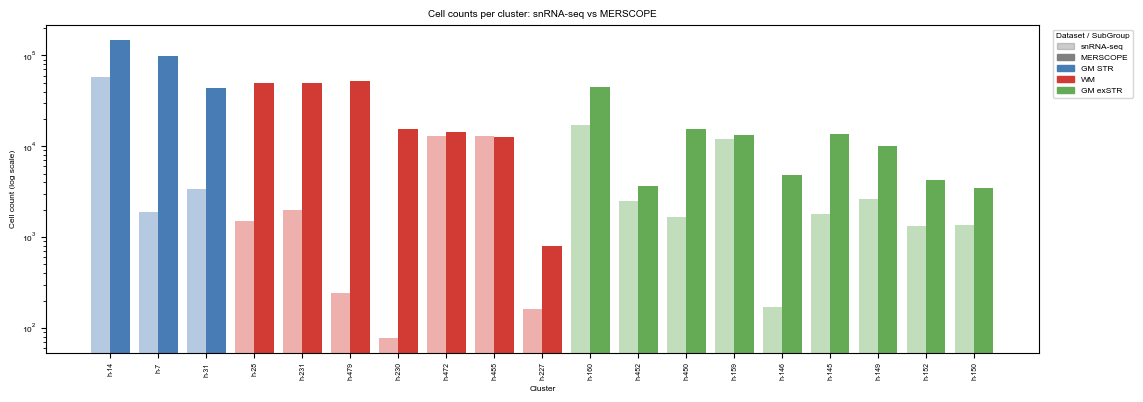

In [151]:
# plot
fig, ax = plt.subplots(figsize=(n_clusters * 0.6, 4))

bar_width = 0.4
x = np.arange(len(cluster_order))
cluster_pos = {c: i for i, c in enumerate(cluster_order)}

# Add SubGroup color mapping to combined_sizes
combined_sizes['SubGroup'] = combined_sizes['cluster_id'].map(
    obs.drop_duplicates('cluster_id_short').set_index('cluster_id_short')['SubGroup']
)

for _, row in combined_sizes.iterrows():
    if row['cluster_id'] not in cluster_pos:
        continue
    xi = cluster_pos[row['cluster_id']]
    color = subgroup_color_palette.get(row['SubGroup'], '#cccccc')
    if row['dataset'] == 'snRNA-seq':
        ax.bar(xi - bar_width / 2, row['count'], width=bar_width,
               color=color, alpha=0.4, edgecolor='none')
    else:  # MERSCOPE
        ax.bar(xi + bar_width / 2, row['count'], width=bar_width,
               color=color, alpha=1.0, edgecolor='none')


ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(cluster_order, rotation=90, fontsize=5)
ax.set_xlabel('Cluster')
ax.set_ylabel('Cell count (log scale)')
ax.set_title('Cell counts per cluster: snRNA-seq vs MERSCOPE')

from matplotlib.patches import Patch
legend_handles = [
    Patch(color='gray', alpha=0.4, label='snRNA-seq'),
    Patch(color='gray', alpha=1.0, label='MERSCOPE'),
] + [Patch(color=subgroup_color_palette[sg], label=sg) for sg in astro_subgroups]
ax.legend(handles=legend_handles, title='Dataset / SubGroup',
          bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=6)

plt.tight_layout()
plt.show()

fig.savefig(os.path.join(output_fig_dir, 'cluster_cell_counts_split_barplot.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(output_fig_dir, 'cluster_cell_counts_split_barplot.png'), bbox_inches='tight', dpi=300)

/tmp/ipykernel_7587/1791053371.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{abs(int(t))}' for t in yticks])


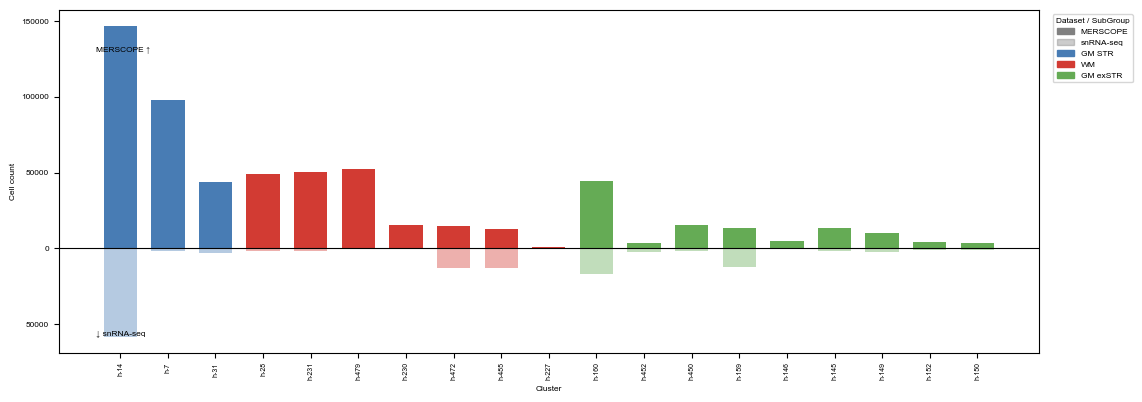

In [156]:
# plot - mirrored barplot: MERSCOPE up, snRNA-seq down
fig, ax = plt.subplots(figsize=(n_clusters * 0.6, 4))

bar_width = 0.7  # single bar per cluster, no side-by-side
x = np.arange(len(cluster_order))
cluster_pos = {c: i for i, c in enumerate(cluster_order)}

# pivot combined_sizes for easy lookup
sizes_pivot = combined_sizes.set_index(['cluster_id', 'dataset'])['count']

for c, xi in cluster_pos.items():
    color = subgroup_color_palette.get(
        cluster_means.loc[cluster_means['cluster_id_short'] == c, 'SubGroup'].values[0], '#cccccc'
    )
    merscope_count = sizes_pivot.get((c, 'MERSCOPE'), 0)
    rnaseq_count   = sizes_pivot.get((c, 'snRNA-seq'), 0)

    ax.bar(xi,  merscope_count, width=bar_width, color=color, alpha=1.0, edgecolor='none')
    ax.bar(xi, -rnaseq_count,  width=bar_width, color=color, alpha=0.4, edgecolor='none')

# symmetric log scale on y
# ax.set_yscale('symlog')
ax.axhline(0, color='black', linewidth=0.8)

# y-axis: show absolute values as labels
yticks = ax.get_yticks()
ax.set_yticklabels([f'{abs(int(t))}' for t in yticks])

ax.set_xticks(x)
ax.set_xticklabels(cluster_order, rotation=90, fontsize=5)
ax.set_xlabel('Cluster')
ax.set_ylabel('Cell count')

# axis labels for up/down
ax.text(-0.5, ax.get_ylim()[1] * 0.85, 'MERSCOPE ↑', fontsize=6, va='top')
ax.text(-0.5, ax.get_ylim()[0] * 0.85, '↓ snRNA-seq', fontsize=6, va='bottom')

from matplotlib.patches import Patch
legend_handles = [
    Patch(color='gray', alpha=1.0, label='MERSCOPE'),
    Patch(color='gray', alpha=0.4, label='snRNA-seq'),
] + [Patch(color=subgroup_color_palette[sg], label=sg) for sg in astro_subgroups]
ax.legend(handles=legend_handles, title='Dataset / SubGroup',
          bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=6)

plt.tight_layout()
plt.show()

fig.savefig(os.path.join(output_fig_dir, 'cluster_cell_counts_mirror_barplot.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(output_fig_dir, 'cluster_cell_counts_mirror_barplot.png'), bbox_inches='tight', dpi=300)

In [ ]:
# scatter plot of cluster pop size vs bootstrapping probability, colored by SubGroup
# Left: MERSCOPE cluster size vs spatial bootstrapping probability
# Right: snRNA-seq cluster size vs spatial bootstrapping probability
from scipy import stats

# Compute per-cluster mean bootstrapping probability from obs
cluster_boot_prob = (
    obs[obs['SubGroup'].isin(astro_subgroups)]
    .groupby('cluster_id_short', observed=True)['cluster_id_bootstrapping_probability']
    .mean()
    .reset_index()
    .rename(columns={'cluster_id_bootstrapping_probability': 'mean_boot_prob'})
)

# Merge with spatial and rnaseq cluster sizes
sizes_pivot = combined_sizes.pivot_table(index='cluster_id', columns='dataset', values='count').reset_index()
sizes_pivot.columns.name = None
sizes_pivot = sizes_pivot.rename(columns={'MERSCOPE': 'merscope_count', 'snRNA-seq': 'rnaseq_count'})
sizes_pivot = sizes_pivot.merge(cluster_boot_prob, left_on='cluster_id', right_on='cluster_id_short', how='left')
sizes_pivot['SubGroup'] = sizes_pivot['cluster_id'].map(
    cluster_means.set_index('cluster_id_short')['SubGroup']
)

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

for ax, (x_col, xlabel) in zip(axes, [
    ('merscope_count', 'MERSCOPE cluster size'),
    ('rnaseq_count',   'snRNA-seq cluster size'),
]):
    for sg in astro_subgroups:
        sub = sizes_pivot[sizes_pivot['SubGroup'] == sg]
        ax.scatter(
            sub[x_col], sub['mean_boot_prob'],
            color=subgroup_color_palette[sg],
            label=sg, s=30, alpha=0.8, edgecolors='none',
        )

    # best-fit line across all subgroups (log-x space)
    plot_data = sizes_pivot[[x_col, 'mean_boot_prob']].dropna()
    log_x = np.log10(plot_data[x_col])
    y = plot_data['mean_boot_prob']
    slope, intercept, r, p, _ = stats.linregress(log_x, y)
    x_fit = np.linspace(log_x.min(), log_x.max(), 100)
    y_fit = slope * x_fit + intercept
    ax.plot(10**x_fit, y_fit, color='black', linewidth=1, linestyle='--',
            label=f'r={r:.2f}, p={p:.3f}')
    ax.text(0.05, 0.05, f'r={r:.2f}\np={p:.3f}', transform=ax.transAxes,
            fontsize=6, va='bottom')

    ax.set_xlabel(xlabel)
    ax.set_xscale('log')
    ax.set_ylim(0.6, 1.0)

axes[0].set_ylabel('Mean cluster-level bootstrapping probability')

from matplotlib.patches import Patch
legend_handles = [Patch(color=subgroup_color_palette[sg], label=sg) for sg in astro_subgroups]
axes[1].legend(handles=legend_handles, title='SubGroup', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=6)

plt.tight_layout()
plt.show()

fig.savefig(os.path.join(output_fig_dir, 'cluster_size_vs_bootstrap_prob_scatter.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(output_fig_dir, 'cluster_size_vs_bootstrap_prob_scatter.png'), bbox_inches='tight', dpi=300)


KeyError: 'SubGroup'

/tmp/ipykernel_7587/1385953056.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


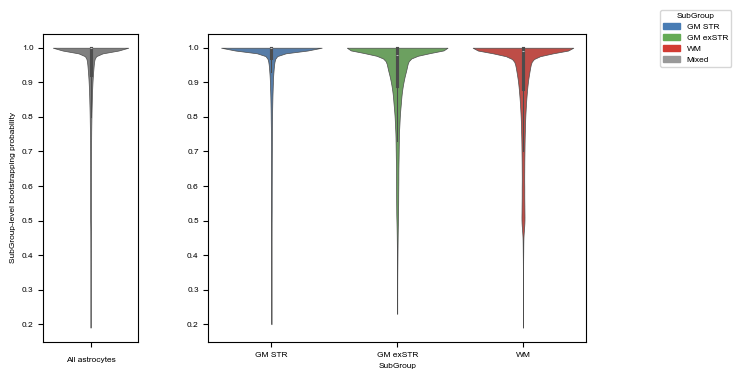

In [16]:
# Build obs dataframe with SubGroup info for coloring
obs = adata_spatial_remap.obs.copy()
obs['SubGroup'] = obs['cluster_id_extended'].map(cluster_subgroup_dict)

astro_subgroups = ['GM STR', 'GM exSTR', 'WM']  #, 'Mixed']

from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(7, 4))
gs = GridSpec(1, 2, figure=fig, width_ratios=[1, 4], wspace=0.3)

# --- Panel 0: single violin, all astrocytes combined ---
ax0 = fig.add_subplot(gs[0])
sns.violinplot(
    y='CDM_SubGroup_bootstrapping_probability',
    data=obs[obs['SubGroup'].isin(astro_subgroups)],
    color='gray',
    inner='box',
    linewidth=0.5,
    ax=ax0,
    cut=0
)
ax0.set_xlabel('All astrocytes')
ax0.set_ylabel('SubGroup-level bootstrapping probability')
# ax0.set_ylim(0, 1)

# --- Panel 1: one violin per subgroup ---
ax1 = fig.add_subplot(gs[1])
sg_order = astro_subgroups
sg_palette = [subgroup_color_palette[sg] for sg in sg_order]
sns.violinplot(
    x='SubGroup',
    y='CDM_SubGroup_bootstrapping_probability',
    data=obs[obs['SubGroup'].isin(astro_subgroups)],
    order=sg_order,
    palette=sg_palette,
    inner='box',
    linewidth=0.5,
    ax=ax1,
    cut=0
)
ax1.set_xlabel('SubGroup')
ax1.set_ylabel('')
# ax1.set_ylim(0, 1)

# shared legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=sg) for sg, c in subgroup_color_palette.items()]
fig.legend(handles=legend_handles, title='SubGroup', bbox_to_anchor=(1.0, 0.95), loc='upper left', fontsize=6)

fig.savefig(os.path.join(output_fig_dir, 'spatial_astro_CDM_subgroup_bootstrap_prob_violin.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(output_fig_dir, 'spatial_astro_CDM_subgroup_bootstrap_prob_violin.png'), dpi=300, bbox_inches='tight')
plt.show()

In [17]:
sorted(adata_spatial_remap.obs.columns.tolist())

['CDM_Class_aggregate_probability',
 'CDM_Class_avg_correlation',
 'CDM_Class_bootstrapping_probability',
 'CDM_Class_directly_assigned',
 'CDM_Class_label',
 'CDM_Class_name',
 'CDM_Class_runner_up_assignment_0',
 'CDM_Class_runner_up_assignment_1',
 'CDM_Class_runner_up_assignment_2',
 'CDM_Class_runner_up_assignment_3',
 'CDM_Class_runner_up_assignment_4',
 'CDM_Class_runner_up_assignment_5',
 'CDM_Class_runner_up_assignment_6',
 'CDM_Class_runner_up_assignment_7',
 'CDM_Class_runner_up_correlation_0',
 'CDM_Class_runner_up_correlation_1',
 'CDM_Class_runner_up_correlation_2',
 'CDM_Class_runner_up_correlation_3',
 'CDM_Class_runner_up_correlation_4',
 'CDM_Class_runner_up_correlation_5',
 'CDM_Class_runner_up_correlation_6',
 'CDM_Class_runner_up_correlation_7',
 'CDM_Class_runner_up_probability_0',
 'CDM_Class_runner_up_probability_1',
 'CDM_Class_runner_up_probability_2',
 'CDM_Class_runner_up_probability_3',
 'CDM_Class_runner_up_probability_4',
 'CDM_Class_runner_up_probability

In [18]:
adata_spatial_remap.obs['CDM_SubGroup_runner_up_assignment_0'] = adata_spatial_remap.obs['CDM_SubGroup_runner_up_assignment_0'].astype('category')
adata_spatial_remap.obs['CDM_SubGroup_label'] = adata_spatial_remap.obs['CDM_SubGroup_label'].astype('category')

In [20]:
adata_spatial_remap.obs['CDM_SubGroup_runner_up_assignment_0'].cat.categories

Index(['AMY-SLEA-BNST D1 GABA', 'AMY-SLEA-BNST GABA', 'Adjacent', 'B cells',
       'BAM', 'BF SKOR1 Glut', 'COP', 'Endo', 'Ependymal', 'GM STR',
       'GM exSTR', 'GPe MEIS2-SOX6 GABA', 'GPe SOX6-CTXND1 GABA',
       'GPe-NDB-SI LHX6-LHX8-GBX1 GABA', 'GPi Core', 'GPi Shell',
       'GPin-BF Cholinergic GABA', 'ImAstro', 'ImOligo', 'LAMP5-CXCL14 GABA',
       'LAMP5-LHX6 GABA', 'Microglia', 'Mixed', 'Monocyte', 'OB Dopa-GABA',
       'OB FRMD7 GABA', 'OPC', 'OT D1 ICj', 'Oligo OPALIN', 'Oligo PLEKHG1',
       'Pericyte', 'SMC', 'SN EBF2 GABA', 'SN GATA3-PVALB GABA',
       'SN SEMA5A GABA', 'SN SOX6 Dopa', 'SN-VTR CALB1 Dopa',
       'SN-VTR GAD2 Dopa', 'SN-VTR-HTH GATA3-TCF7L2 GABA',
       'STH PVALB-PITX2 Glut', 'STR Cholinergic GABA', 'STR D1D2 Hybrid MSN',
       'STR FS PTHLH-PVALB GABA', 'STR LYPD6-RSPO2 GABA',
       'STR SST-ADARB2 GABA', 'STR SST-CHODL GABA', 'STR SST-RSPO2 GABA',
       'STR TAC3-PLPP4 GABA', 'STR-BF TAC3-PLPP4-LHX8 GABA',
       'STRd Cholinergic GABA', 'S

In [22]:
adata_spatial_remap.obs['CDM_SubGroup_runner_up_assignment_0'] = adata_spatial_remap.obs['CDM_SubGroup_runner_up_assignment_0'].cat.add_categories('None')
adata_spatial_remap.obs['CDM_SubGroup_runner_up_assignment_0'].fillna('None')

cell_label
1321115602_26          None
1321115602_32         Mixed
1321115602_39         Mixed
1321115602_41          None
1321115602_44          None
                     ...   
1384732991_84452       None
1384732991_84453       None
1384732991_84461       None
1384732991_84472    T cells
1384732991_84491      Mixed
Name: CDM_SubGroup_runner_up_assignment_0, Length: 641913, dtype: category
Categories (64, object): ['AMY-SLEA-BNST D1 GABA', 'AMY-SLEA-BNST GABA', 'Adjacent', 'B cells', ..., 'VLMC', 'VTR-HTH Glut', 'WM', 'None']

In [35]:
obs_new_mapping_astro = adata_spatial_remap.obs[adata_spatial_remap.obs['CDM_Group_label']=="Astrocyte"].copy()
obs_new_mapping_astro

,x,y,brain_section_label,brain_section_barcode,slab,block,set,z_order,total_counts,total_counts_genes,...,CDM_SubGroup_runner_up_probability_11,CDM_Class_runner_up_assignment_6,CDM_Class_runner_up_correlation_6,CDM_Class_runner_up_probability_6,CDM_cluster_id_runner_up_assignment_15,CDM_cluster_id_runner_up_correlation_15,CDM_cluster_id_runner_up_probability_15,CDM_Class_runner_up_assignment_7,CDM_Class_runner_up_correlation_7,CDM_Class_runner_up_probability_7
cell_label,,,,,,,,,,,,,,,,,,,,,
1321115602_26,2952.413818,1081.064819,H22.30.001.CX.16.05.05.03,1321115602,CX.16,5,5,6,101,101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1321115602_32,2904.200684,1114.436646,H22.30.001.CX.16.05.05.03,1321115602,CX.16,5,5,6,203,203,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1321115602_39,2920.945801,1132.869751,H22.30.001.CX.16.05.05.03,1321115602,CX.16,5,5,6,154,154,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1321115602_41,2844.331299,1148.932739,H22.30.001.CX.16.05.05.03,1321115602,CX.16,5,5,6,228,228,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1321115602_44,3175.939697,1163.299683,H22.30.001.CX.16.05.05.03,1321115602,CX.16,5,5,6,189,188,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384732991_84452,8126.525391,1141.643066,H22.30.001.CX.20.02.05.01,1384732991,CX.20,2,5,16,120,120,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1384732991_84453,7888.952148,1144.162354,H22.30.001.CX.20.02.05.01,1384732991,CX.20,2,5,16,83,83,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1384732991_84461,8005.833008,1174.518433,H22.30.001.CX.20.02.05.01,1384732991,CX.20,2,5,16,291,290,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
obs_new_mapping_astro[['CDM_SubGroup_label',
    'CDM_SubGroup_runner_up_assignment_0',]][~(obs_new_mapping_astro['CDM_SubGroup_runner_up_assignment_0'].isna())].head(20)

,CDM_SubGroup_label,CDM_SubGroup_runner_up_assignment_0
cell_label,,
1321115602_32,GM STR,Mixed
1321115602_39,GM STR,Mixed
1321115602_54,GM STR,Mixed
1321115602_78,GM STR,GM exSTR
1321115602_79,GM STR,ImAstro
1321115602_84,GM STR,ImAstro
1321115602_85,GM STR,Mixed
1321115602_87,GM STR,Mixed
1321115602_131,GM STR,ImAstro


In [25]:
for thresh in [0.80, 0.90, 0.95, 0.99, 1.0]:
    for level in ['CDM_Neighborhood', 'CDM_Class', 'CDM_Subclass', 'CDM_Group', 'CDM_SubGroup', 'CDM_cluster_id']:
        fraction_perfect = (obs_new_mapping_astro[f'{level}_bootstrapping_probability'] >= thresh).mean()
        print(f"Fraction of cells with bootstrapping probability >= {thresh:.2f} for {level}: {fraction_perfect:.4f}")
    print('')

# for level in ['CDM_Neighborhood', 'CDM_Class', 'CDM_Subclass', 'CDM_Group', 'CDM_SubGroup', 'CDM_cluster_id']:
#     fraction_perfect = (obs_new_mapping_astro[f'{level}_bootstrapping_probability'] >= 0.950).mean()
#     print(f"Fraction of cells with bootstrapping probability >= 0.95 for {level}: {fraction_perfect:.4f}")
# print('')
# for level in ['CDM_Neighborhood', 'CDM_Class', 'CDM_Subclass', 'CDM_Group', 'CDM_SubGroup', 'CDM_cluster_id']:
#     fraction_perfect = (obs_new_mapping_astro[f'{level}_bootstrapping_probability'] >= 0.90).mean()
#     print(f"Fraction of cells with bootstrapping probability >= 0.80 for {level}: {fraction_perfect:.4f}")

Fraction of cells with bootstrapping probability >= 0.80 for CDM_Neighborhood: 0.9967
Fraction of cells with bootstrapping probability >= 0.80 for CDM_Class: 0.9851
Fraction of cells with bootstrapping probability >= 0.80 for CDM_Subclass: 0.9796
Fraction of cells with bootstrapping probability >= 0.80 for CDM_Group: 0.9639
Fraction of cells with bootstrapping probability >= 0.80 for CDM_SubGroup: 0.8791
Fraction of cells with bootstrapping probability >= 0.80 for CDM_cluster_id: 0.7136

Fraction of cells with bootstrapping probability >= 0.90 for CDM_Neighborhood: 0.9905
Fraction of cells with bootstrapping probability >= 0.90 for CDM_Class: 0.9608
Fraction of cells with bootstrapping probability >= 0.90 for CDM_Subclass: 0.9495
Fraction of cells with bootstrapping probability >= 0.90 for CDM_Group: 0.9191
Fraction of cells with bootstrapping probability >= 0.90 for CDM_SubGroup: 0.7888
Fraction of cells with bootstrapping probability >= 0.90 for CDM_cluster_id: 0.5515

Fraction of ce

In [31]:
obs_new_mapping_astro['CDM_SubGroup_label'] = obs_new_mapping_astro['CDM_SubGroup_label'].cat.remove_unused_categories()

In [70]:
obs_new_mapping_astro_subgroups = obs_new_mapping_astro[
    (obs_new_mapping_astro['CDM_SubGroup_label'].isin(['GM STR', 'GM exSTR', 'WM'])) & 
    (obs_new_mapping_astro['CDM_SubGroup_runner_up_assignment_0'].isin(['GM STR', 'GM exSTR', 'WM']))
].copy()

In [71]:
obs_new_mapping_astro_subgroups['CDM_SubGroup_label'] = obs_new_mapping_astro_subgroups['CDM_SubGroup_label'].cat.remove_unused_categories()
obs_new_mapping_astro_subgroups['CDM_SubGroup_runner_up_assignment_0'] = obs_new_mapping_astro_subgroups['CDM_SubGroup_runner_up_assignment_0'].cat.remove_unused_categories()

obs_new_mapping_astro_subgroups['CDM_cluster_id_label'] = obs_new_mapping_astro_subgroups['CDM_cluster_id_label'].cat.remove_unused_categories()
obs_new_mapping_astro_subgroups['CDM_cluster_id_runner_up_assignment_0'] = obs_new_mapping_astro_subgroups['CDM_cluster_id_runner_up_assignment_0'].cat.remove_unused_categories()

In [72]:
# set subGroup order
all_subGroups_ordered = ['GM STR', 'GM exSTR', 'WM']
obs_new_mapping_astro_subgroups['CDM_SubGroup_label'] = obs_new_mapping_astro_subgroups['CDM_SubGroup_label'].cat.set_categories(all_subGroups_ordered, ordered=True)
obs_new_mapping_astro_subgroups['CDM_SubGroup_runner_up_assignment_0'] = obs_new_mapping_astro_subgroups['CDM_SubGroup_runner_up_assignment_0'].cat.set_categories(all_subGroups_ordered, ordered=True)

In [77]:
# convert all the mapped cluster names from format "Human-7" to "h-7"
obs_new_mapping_astro_subgroups['CDM_cluster_id_label_h'] = obs_new_mapping_astro_subgroups['CDM_cluster_id_label'].str.replace('Human-', 'h-')
obs_new_mapping_astro_subgroups['CDM_cluster_id_runner_up_assignment_0_h'] = obs_new_mapping_astro_subgroups['CDM_cluster_id_runner_up_assignment_0'].str.replace('Human-', 'h-')
obs_new_mapping_astro_subgroups['CDM_cluster_id_label_h'] = obs_new_mapping_astro_subgroups['CDM_cluster_id_label_h'].astype('category')
obs_new_mapping_astro_subgroups['CDM_cluster_id_runner_up_assignment_0_h'] = obs_new_mapping_astro_subgroups['CDM_cluster_id_runner_up_assignment_0_h'].astype('category')
obs_new_mapping_astro_subgroups['CDM_cluster_id_label_h'] = obs_new_mapping_astro_subgroups['CDM_cluster_id_label_h'].cat.remove_unused_categories()
obs_new_mapping_astro_subgroups['CDM_cluster_id_runner_up_assignment_0_h'] = obs_new_mapping_astro_subgroups['CDM_cluster_id_runner_up_assignment_0_h'].cat.remove_unused_categories()

In [81]:
# count nans in the cluster columns
print("NaN counts in CDM_cluster_id columns:")
print(obs_new_mapping_astro_subgroups['CDM_cluster_id_label'].isna().sum())
print(obs_new_mapping_astro_subgroups['CDM_cluster_id_runner_up_assignment_0'].isna().sum())

NaN counts in CDM_cluster_id columns:
0
0


In [79]:

# need to transfer the subGroup labels for the self-mapping cluster results
# make a mapping for each unique cluster label to the subGroup label, confirming all cells in a cluster share the same subGroup label
cluster_to_subgroup = {}
for cluster in obs_new_mapping_astro_subgroups['CDM_cluster_id_label_h'].unique():
    cluster_cells = obs_new_mapping_astro_subgroups[obs_new_mapping_astro_subgroups['CDM_cluster_id_label_h'] == cluster]
    unique_subgroups = cluster_cells['CDM_SubGroup_label'].unique()
    assert len(unique_subgroups) == 1, f"Cluster {cluster} has multiple subGroups: {unique_subgroups}"
    cluster_to_subgroup[cluster] = unique_subgroups[0]

def sort_cluster_labels(labels):
    '''Sort cluster labels in the format "Human-7" by the numeric part of the label.'''
    def sort_key(label):
        parts = label.split('-') # sort by the cluster id # only
        num_part = parts[-1] if parts[-1].isdigit() else ''
        return num_part.zfill(5) if num_part else label  # pad with leading zeros for correct lexicographic ordering
    return sorted(labels, key=sort_key)
    
group_to_cluster_list = {}
for cluster, subgroup in cluster_to_subgroup.items():
    if subgroup not in group_to_cluster_list:
        group_to_cluster_list[subgroup] = []
    group_to_cluster_list[subgroup].append(cluster)

for group, cluster_list in group_to_cluster_list.items():
    # sort the cluster list for each group
    sorted_list = sort_cluster_labels(cluster_list)
    # display(sorted_list)
    group_to_cluster_list[group] = sorted_list
display(group_to_cluster_list)

# set the cat order for both columns based on the joined sorted cluster lists
cat_order = [sublist for group in group_to_cluster_list.values() for sublist in group]
display(cat_order)

obs_new_mapping_astro_subgroups['CDM_cluster_id_label_h'] = pd.Categorical(
    obs_new_mapping_astro_subgroups['CDM_cluster_id_label_h'],
    categories=cat_order,
    ordered=True
)
obs_new_mapping_astro_subgroups['CDM_cluster_id_runner_up_assignment_0_h'] = pd.Categorical(
    obs_new_mapping_astro_subgroups['CDM_cluster_id_runner_up_assignment_0_h'],
    categories=cat_order,
    ordered=True
)

{'GM STR': ['h-7', 'h-14', 'h-31'],
 'WM': ['h-28', 'h-227', 'h-230', 'h-231', 'h-472', 'h-479', 'h-485'],
 'GM exSTR': ['h-145',
  'h-146',
  'h-149',
  'h-150',
  'h-152',
  'h-159',
  'h-160',
  'h-450',
  'h-452']}

['h-7',
 'h-14',
 'h-31',
 'h-28',
 'h-227',
 'h-230',
 'h-231',
 'h-472',
 'h-479',
 'h-485',
 'h-145',
 'h-146',
 'h-149',
 'h-150',
 'h-152',
 'h-159',
 'h-160',
 'h-450',
 'h-452']

In [86]:
obs_new_mapping_astro_subgroups['CDM_cluster_id_runner_up_assignment_0_h']

cell_label
1321115602_78       h-145
1321115602_290      h-145
1321115602_415      h-145
1321115602_583      h-479
1321115602_634      h-145
                    ...  
1384732991_83357    h-145
1384732991_83437    h-479
1384732991_83469    h-159
1384732991_83761    h-160
1384732991_83849     h-28
Name: CDM_cluster_id_runner_up_assignment_0_h, Length: 85213, dtype: category
Categories (19, object): ['h-7' < 'h-14' < 'h-31' < 'h-28' ... 'h-159' < 'h-160' < 'h-450' < 'h-452']

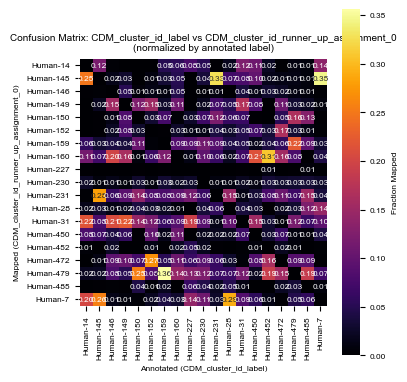

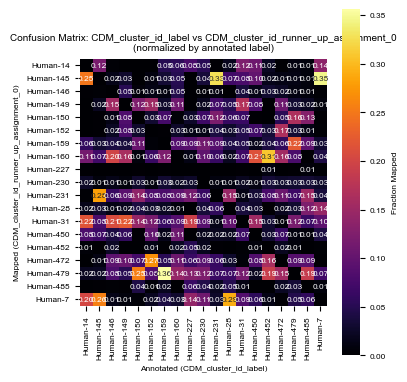

In [92]:
plot_confusion_matrix(
    obs_new_mapping_astro_subgroups,
    'CDM_cluster_id_label',
    'CDM_cluster_id_runner_up_assignment_0',
)

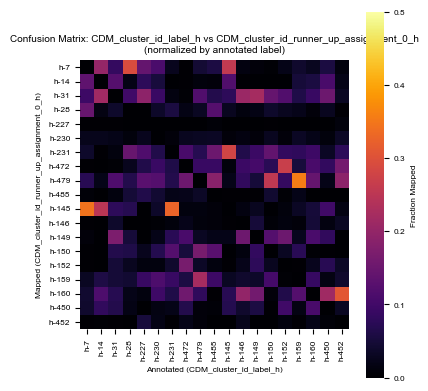

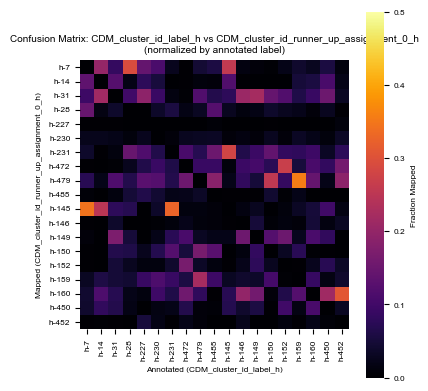

In [96]:
plot_confusion_matrix(
    obs_new_mapping_astro_subgroups,
    'CDM_cluster_id_label_h',
    'CDM_cluster_id_runner_up_assignment_0_h',
    vlims=(0,0.5),
    annot_values_on_heatmap=False,
)

In [125]:
obs_spatial_subgroups = adata_spatial_remap.obs[
    ['CDM_SubGroup_label',
    'CDM_SubGroup_runner_up_assignment_0']
].copy()

obs_spatial_subgroups = obs_spatial_subgroups[obs_spatial_subgroups['CDM_SubGroup_label'].isin(['GM STR', 'GM exSTR', 'WM'])].copy()
obs_spatial_subgroups['CDM_SubGroup_label'] = obs_spatial_subgroups['CDM_SubGroup_label'].astype('category')
obs_spatial_subgroups['CDM_SubGroup_label'] = obs_spatial_subgroups['CDM_SubGroup_label'].cat.remove_unused_categories()
obs_spatial_subgroups['CDM_SubGroup_label'] = obs_spatial_subgroups['CDM_SubGroup_label'].cat.add_categories('Other')

# replace 'None' with NaN
obs_spatial_subgroups['CDM_SubGroup_runner_up_assignment_0'].replace(
    'None', pd.NA, inplace=True
)
obs_spatial_subgroups

# for entry not in all_subGroups_ordered & not NaN, set to 'Other'
obs_spatial_subgroups['CDM_SubGroup_runner_up_assignment_0'] = obs_spatial_subgroups['CDM_SubGroup_runner_up_assignment_0'].cat.add_categories('Other')
obs_spatial_subgroups['CDM_SubGroup_runner_up_assignment_0'] = obs_spatial_subgroups['CDM_SubGroup_runner_up_assignment_0'].apply(lambda x: x if (x in all_subGroups_ordered or pd.isna(x)) else 'Other')

# fill NaN with the 'CDM_SubGroup_label' value
obs_spatial_subgroups['CDM_SubGroup_runner_up_assignment_0'] = obs_spatial_subgroups.apply(
    lambda row: row['CDM_SubGroup_label'] if pd.isna(row['CDM_SubGroup_runner_up_assignment_0']) else row['CDM_SubGroup_runner_up_assignment_0'],
    axis=1
)
# clean up categories again after filling
obs_spatial_subgroups['CDM_SubGroup_runner_up_assignment_0'] = obs_spatial_subgroups['CDM_SubGroup_runner_up_assignment_0'].astype('category')
obs_spatial_subgroups['CDM_SubGroup_runner_up_assignment_0'] = obs_spatial_subgroups['CDM_SubGroup_runner_up_assignment_0'].cat.remove_unused_categories()


/tmp/ipykernel_7587/1350317044.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  obs_spatial_subgroups['CDM_SubGroup_runner_up_assignment_0'].replace(
/tmp/ipykernel_7587/1350317044.py:12: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  obs_spatial_subgroups['CDM_SubGroup_runner_up_assignment_0'].replace(


In [126]:
obs_spatial_subgroups['CDM_SubGroup_label']

cell_label
1321115602_26       GM STR
1321115602_32       GM STR
1321115602_39       GM STR
1321115602_41       GM STR
1321115602_44       GM STR
                     ...  
1384732991_84452        WM
1384732991_84453        WM
1384732991_84461        WM
1384732991_84472        WM
1384732991_84491        WM
Name: CDM_SubGroup_label, Length: 581697, dtype: category
Categories (4, object): ['GM STR', 'GM exSTR', 'WM', 'Other']

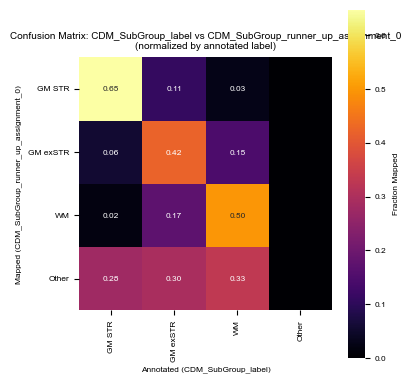

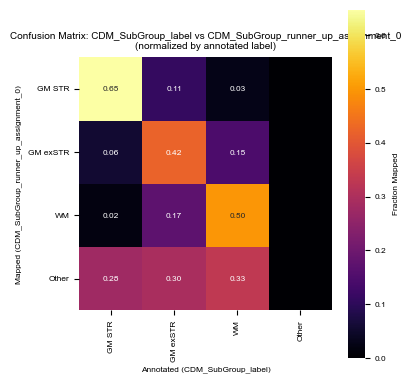

In [127]:
plot_confusion_matrix(
    obs_spatial_subgroups,
    'CDM_SubGroup_label',
    'CDM_SubGroup_runner_up_assignment_0',
)

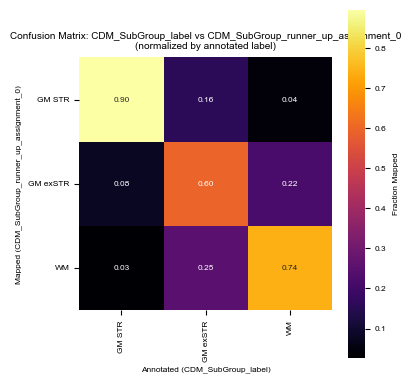

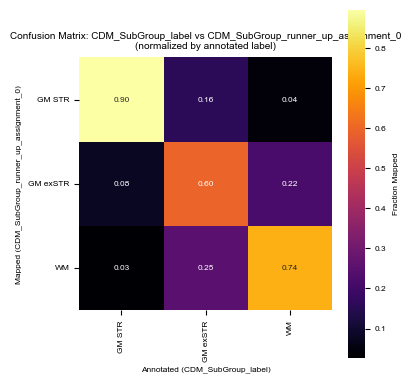

In [165]:
# drop the "Other" category and entries and replot
obs_spatial_subgroups_no_other = obs_spatial_subgroups[
    (obs_spatial_subgroups['CDM_SubGroup_label'] != 'Other') &
    (obs_spatial_subgroups['CDM_SubGroup_runner_up_assignment_0'] != 'Other')
].copy()
# drop the cat
obs_spatial_subgroups_no_other['CDM_SubGroup_label'] = obs_spatial_subgroups_no_other['CDM_SubGroup_label'].cat.remove_unused_categories()
obs_spatial_subgroups_no_other['CDM_SubGroup_runner_up_assignment_0'] = obs_spatial_subgroups_no_other['CDM_SubGroup_runner_up_assignment_0'].cat.remove_unused_categories()

plot_confusion_matrix(
    obs_spatial_subgroups_no_other,
    'CDM_SubGroup_label',
    'CDM_SubGroup_runner_up_assignment_0',
)

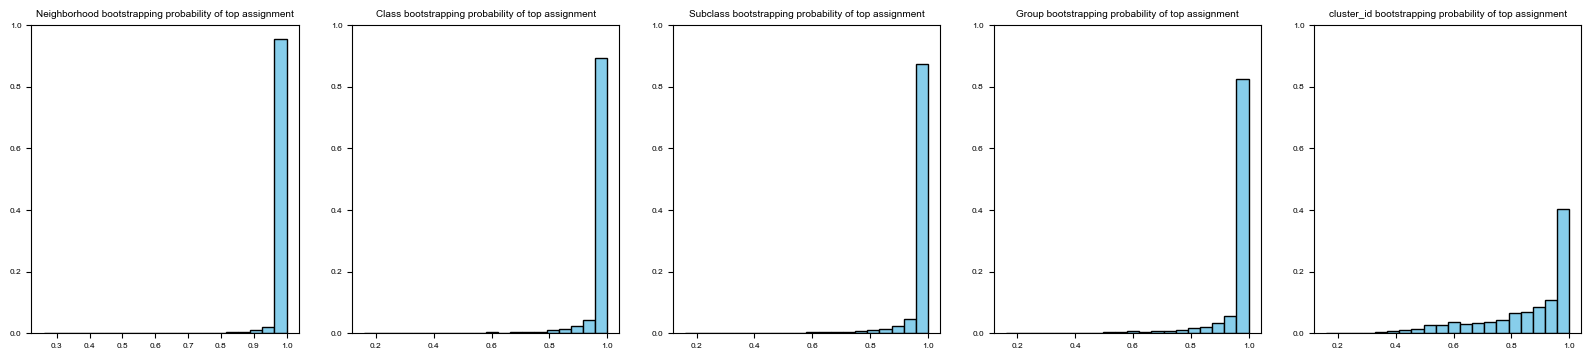

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, level in enumerate(['Neighborhood', 'Class', 'Subclass', 'Group', 'cluster_id']):
    # histogram of bootstrapping probabilities for each level
    ax = axes[i]  # use the first subplot for all histograms

    data = adata_spatial_astro_extended.obs[f'{level}_bootstrapping_probability'].dropna()
    weights = np.ones_like(data) / len(data)
    ax.hist(
        data, 
        bins=20, 
        color='skyblue', 
        edgecolor='black',
        weights=weights
    )
    ax.set_title(f'{level} bootstrapping probability of top assignment')
    ax.set_ylim(0, 1)
plt.show()

fig.savefig(os.path.join(output_fig_dir, 'astrocyte_spatial_bootstrapping_probability_by_level.pdf'), bbox_inches='tight')
fig.savefig(os.path.join(output_fig_dir, 'astrocyte_spatial_bootstrapping_probability_by_level.png'), dpi=300, bbox_inches='tight')

In [15]:
# fraction of cells that map to the same cluster (boot prob = 1.0)
for level in ['Neighborhood', 'Class', 'Subclass', 'Group', 'cluster_id']:
    fraction_perfect = (adata_spatial_astro_extended.obs[f'{level}_bootstrapping_probability'] == 1.0).mean()
    print(f"Fraction of cells with bootstrapping probability of 1.0 for {level}: {fraction_perfect:.4f}")

Fraction of cells with bootstrapping probability of 1.0 for Neighborhood: 0.9308
Fraction of cells with bootstrapping probability of 1.0 for Class: 0.8357
Fraction of cells with bootstrapping probability of 1.0 for Subclass: 0.8078
Fraction of cells with bootstrapping probability of 1.0 for Group: 0.7248
Fraction of cells with bootstrapping probability of 1.0 for cluster_id: 0.2330


In [16]:
# fraction of cells that map to the same cluster (boot prob = 1.0)
for level in ['Neighborhood', 'Class', 'Subclass', 'Group', 'cluster_id']:
    fraction_perfect = (adata_spatial_astro_extended.obs[f'{level}_bootstrapping_probability'] >= 0.95).mean()
    print(f"Fraction of cells with bootstrapping probability of 1.0 for {level}: {fraction_perfect:.4f}")

Fraction of cells with bootstrapping probability of 1.0 for Neighborhood: 0.9683
Fraction of cells with bootstrapping probability of 1.0 for Class: 0.9059
Fraction of cells with bootstrapping probability of 1.0 for Subclass: 0.8887
Fraction of cells with bootstrapping probability of 1.0 for Group: 0.8425
Fraction of cells with bootstrapping probability of 1.0 for cluster_id: 0.4330


In [22]:
# fraction of cells that map to the same cluster (boot prob = 1.0)
for level in ['Neighborhood', 'Class', 'Subclass', 'Group', 'cluster_id']:
    fraction_perfect = (adata_spatial_astro_extended.obs[f'{level}_bootstrapping_probability'] >= 0.80).mean()
    print(f"Fraction of cells with bootstrapping probability of 1.0 for {level}: {fraction_perfect:.4f}")

Fraction of cells with bootstrapping probability of 1.0 for Neighborhood: 0.9936
Fraction of cells with bootstrapping probability of 1.0 for Class: 0.9775
Fraction of cells with bootstrapping probability of 1.0 for Subclass: 0.9703
Fraction of cells with bootstrapping probability of 1.0 for Group: 0.9517
Fraction of cells with bootstrapping probability of 1.0 for cluster_id: 0.7207


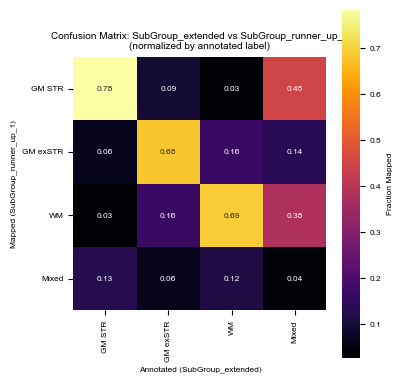

In [18]:
adata_spatial_astro_bp_not_1 = adata_spatial_astro_extended[adata_spatial_astro_extended.obs['cluster_id_bootstrapping_probability'] < 1.0, :].copy()
adata_spatial_astro_bp_not_1

cm_fig = plot_confusion_matrix(
    adata_spatial_astro_bp_not_1.obs,
    'SubGroup_extended',
    'SubGroup_runner_up_1',
)

cm_fig.savefig(os.path.join(output_fig_dir, 'astrocyte_spatial_confusion_matrix_runner_up_1_boot_prob_not_1.pdf'), bbox_inches='tight')
cm_fig.savefig(os.path.join(output_fig_dir, 'astrocyte_spatial_confusion_matrix_runner_up_1_boot_prob_not_1.png'), dpi=300, bbox_inches='tight')

In [ ]:
adata_spatial_astro_bp_not_1 = adata_spatial_astro_extended[adata_spatial_astro_extended.obs['cluster_id_bootstrapping_probability'] < 1.0, :].copy()
adata_spatial_astro_bp_not_1

cm_fig = plot_confusion_matrix(
    adata_spatial_astro_bp_not_1.obs,
    'SubGroup_extended',
    'SubGroup_runner_up_1',
)

cm_fig.savefig(os.path.join(output_fig_dir, 'astrocyte_spatial_confusion_matrix_runner_up_1_boot_prob_not_1.pdf'), bbox_inches='tight')
cm_fig.savefig(os.path.join(output_fig_dir, 'astrocyte_spatial_confusion_matrix_runner_up_1_boot_prob_not_1.png'), dpi=300, bbox_inches='tight')

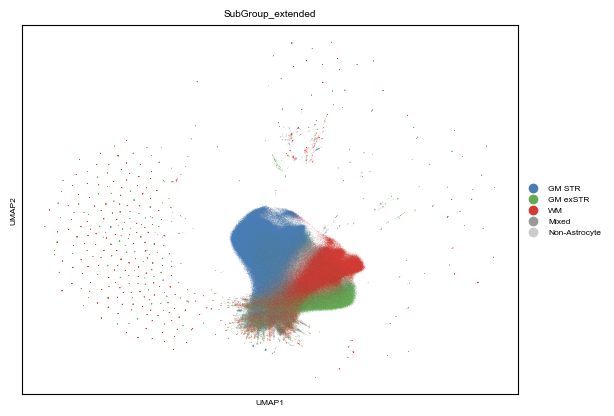

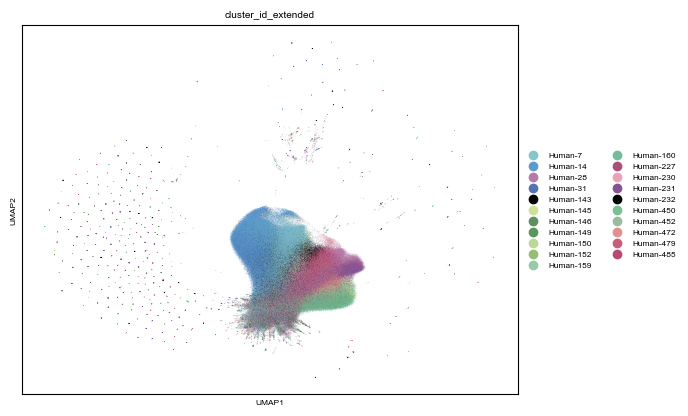

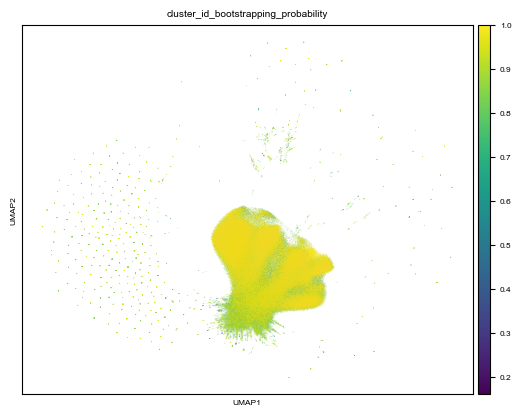

In [19]:
# plot colored by SubGroup
fig_umap_subgroup = sc.pl.umap(
    adata_spatial_astro_extended, 
    color='SubGroup_extended',
    return_fig=True,
    show=True,
)

fig_umpa_cluster = sc.pl.umap(
    adata_spatial_astro_extended, 
    color='cluster_id_extended',
    return_fig=True,
    show=True
)

fig_umap_bootstrap_prob = sc.pl.umap(
    adata_spatial_astro_extended, 
    color='cluster_id_bootstrapping_probability',
    return_fig=True,
    show=True
)

#### F1 Score for Bootstrapping Probability

In [20]:
# Copied directly from Scott's cell_type_mapper package (too lazy to import)
# https://github.com/AllenInstitute/cell_type_mapper/blob/15f9b0b1767d4937f5fd0652d303b9590eb75249/garage/siletti/f1_plots.py

def plot_f1(mapping, truth, axis, level, taxonomy_tree, fontsize=20):
    '''
    Calculate and plot F1 score for each node at the level based on the mapping and truth.

    Parameters:
        mapping: dict of cell_id -> {level: {assignment: label, bootstrapping_probability: prob}}
                 Probably, `_extended_results.json` file generated by MMC
        truth: dict of cell_id -> {level: label}
               Either the actual annotation (when self-mapping the annotated 
               snRNA-seq data) or the "assigned" consensus label from mapping 
               (when mapping unannotated and/or spatial data)
        axis: matplotlib axis to plot on
        level: level to evaluate (e.g. 'Class', 'Subclass', etc.)
        taxonomy_tree: TaxonomyTree object to get list of nodes at the level and label to name mapping
    '''

    data_lookup = dict()
    for node in taxonomy_tree.nodes_at_level(level):
        data_lookup[node] = {
            # 'tp': 0, 'fp': 0, 'fn': 0
            'true_pos': 0, 'false_pos': 0, 'false_neg': 0
        }

    n_correct = 0
    n_incorrect = 0
    for cell_id in mapping:
        true_label = truth[cell_id][level]
        mapped_label = mapping[cell_id][level]['assignment']
        if true_label == mapped_label:
            data_lookup[true_label]['true_pos'] += 1
            n_correct += 1
        else:
            data_lookup[true_label]['false_neg'] += 1
            data_lookup[mapped_label]['false_pos'] += 1
            n_incorrect += 1

    n_cells = []
    f1 = []
    name = []
    full_tp = 0.0
    full_fn = 0.0
    full_fp =0.0
    for node in data_lookup:
        n = data_lookup[node]['false_neg'] + data_lookup[node]['true_pos']
        tp = data_lookup[node]['true_pos']
        fn = data_lookup[node]['false_neg']
        fp = data_lookup[node]['false_pos']
        full_tp += tp
        full_fn += fn
        full_fp += fp
        if tp ==0 and fp == 0 and fn == 0:
            print(f'skipping {level} {node}')
            continue

        ff = 2*tp/(2*tp+fp+fn)
        n_cells.append(n)
        f1.append(ff)
        name.append(
            taxonomy_tree.label_to_name(level=level, label=node))

    n_cells = np.array(n_cells)
    name = np.array(name)
    f1 = np.array(f1)
    sorted_dex = np.argsort(n_cells)
    name = name[sorted_dex]
    f1 = f1[sorted_dex]
    n_cells = n_cells[sorted_dex]
    #for ii in range(5):
    #    jj = len(n_cells)-1-ii
    #    print(name[jj], n_cells[jj], f1[jj])
    wgt = 0.0
    avg = 0.0
    flat = 0.0
    flat_n = 0.0
    for n, ff in zip(n_cells, f1):
        wgt += n
        avg += n*ff
        if n > 0:
            flat += ff
            flat_n += 1.0
    micro = 2*full_tp/(2*full_tp+full_fp+full_fn)
    print(f'{level} avg f1: {avg/wgt:.2e} -- micro {micro:.2e} '
          f'-- flat {flat/flat_n:.2e} -- corr {n_correct:.2e} incorr {n_incorrect:.2e}')
    axis.scatter(n_cells, f1)
    axis.set_xlabel('Ncells (True Pos + False Neg)', fontsize=fontsize)
    axis.set_ylabel('F1', fontsize=fontsize)

In [21]:
# Draft of putting this in a dataframe:

def calculate_f1_all_levels(
    mapping,
    truth,
    levels=('Neighborhood', 'Class', 'Subclass', 'Group', 'cluster_id'),
):
    '''
    Calculate per-cell-type F1 scores for all levels of the taxonomy.

    Parameters:
        mapping: dict of cell_id -> {level: {assignment: label, bootstrapping_probability: prob}}
                 Probably, `_extended_results.json` file generated by MMC
        truth: dict of cell_id -> {level: label}
               Either the actual annotation (when self-mapping the annotated
               snRNA-seq data) or the "assigned" consensus label from mapping
               (when mapping unannotated and/or spatial data)
        levels: iterable of level names to evaluate

    Returns:
        pd.DataFrame with columns:
            level, node, n_cells, true_pos, false_pos, false_neg, f1,
            weighted_avg_f1, micro_f1, macro_f1
    '''
    records = []

    for level in levels:
        # Accumulate TP/FP/FN per node
        data_lookup = {}
        n_correct = 0
        n_incorrect = 0

        for cell_id in mapping:
            true_label = truth[cell_id][level]
            mapped_label = mapping[cell_id][level]['assignment']

            # Ensure nodes seen in data are tracked even if not pre-seeded
            for label in (true_label, mapped_label):
                if label not in data_lookup:
                    data_lookup[label] = {'true_pos': 0, 'false_pos': 0, 'false_neg': 0}

            if true_label == mapped_label:
                data_lookup[true_label]['true_pos'] += 1
                n_correct += 1
            else:
                data_lookup[true_label]['false_neg'] += 1
                data_lookup[mapped_label]['false_pos'] += 1
                n_incorrect += 1

        # Compute per-node F1 and aggregate stats
        full_tp = full_fp = full_fn = 0.0
        weighted_sum = total_weight = 0.0
        macro_sum = macro_n = 0.0

        for node, counts in data_lookup.items():
            tp = counts['true_pos']
            fp = counts['false_pos']
            fn = counts['false_neg']
            n = tp + fn  # cells truly belonging to this node

            full_tp += tp
            full_fp += fp
            full_fn += fn

            if tp == 0 and fp == 0 and fn == 0:
                continue  # node never seen; skip

            f1 = 2 * tp / (2 * tp + fp + fn)

            records.append({
                'level': level,
                'node': node,
                'n_cells': n,
                'true_pos': tp,
                'false_pos': fp,
                'false_neg': fn,
                'f1': f1,
            })

            # accumulate for summary stats
            weighted_sum += n * f1
            total_weight += n
            macro_sum += f1
            macro_n += 1

        # Attach level-wide summary stats to every row for this level
        micro_f1 = (
            2 * full_tp / (2 * full_tp + full_fp + full_fn)
            if (2 * full_tp + full_fp + full_fn) > 0 else np.nan
        )
        weighted_avg_f1 = weighted_sum / total_weight if total_weight > 0 else np.nan
        macro_f1 = macro_sum / macro_n if macro_n > 0 else np.nan

        # Back-fill summary cols for this level's rows
        for rec in records:
            if rec['level'] == level:
                rec['weighted_avg_f1'] = weighted_avg_f1
                rec['micro_f1'] = micro_f1
                rec['macro_f1'] = macro_f1
                rec['n_correct'] = n_correct
                rec['n_incorrect'] = n_incorrect

        print(
            f'{level:20s}  weighted_avg={weighted_avg_f1:.4f}  '
            f'micro={micro_f1:.4f}  macro={macro_f1:.4f}  '
            f'correct={n_correct}  incorrect={n_incorrect}'
        )

    df = pd.DataFrame(records, columns=[
        'level', 'node', 'n_cells',
        'true_pos', 'false_pos', 'false_neg',
        'f1',
        'weighted_avg_f1', 'micro_f1', 'macro_f1',
        'n_correct', 'n_incorrect',
    ])
    return df

In [ ]:
# calculate F1 scores
mapping = adata_spatial_astro_extended.obs.set_index('cell_id').apply(
    lambda row: {
        'Neighborhood': {
            'assignment': row['Neighborhood'],
            'bootstrapping_probability': row['Neighborhood_bootstrapping_probability']
        },
        'Class': {
            'assignment': row['Class'],
            'bootstrapping_probability': row['Class_bootstrapping_probability']
        },
        'Subclass': {
            'assignment': row['Subclass'],
            'bootstrapping_probability': row['Subclass_bootstrapping_probability']
        },
        'Group': {
            'assignment': row['Group'],
            'bootstrapping_probability': row['Group_bootstrapping_probability']
        },
        'cluster_id': {
            'assignment': row['cluster_id_extended'],
            'bootstrapping_probability': row['cluster_id_bootstrapping_probability']
        }
    },
    axis=1
).to_dict()